In [1]:
# CELL 1 — All imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# CELL 2 — Load dataset
# Housing dataset contains house features and their prices
df = pd.read_csv("Housing.csv")
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
# CELL 3 — Basic inspection
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Shape: (545, 13)

Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Missing values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Data types:
 price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object


In [4]:
# CELL 4 — Summary statistics
df.describe()
# INSIGHT: Look at min/max of price column — huge range means 
# some houses are extremely expensive vs cheap

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


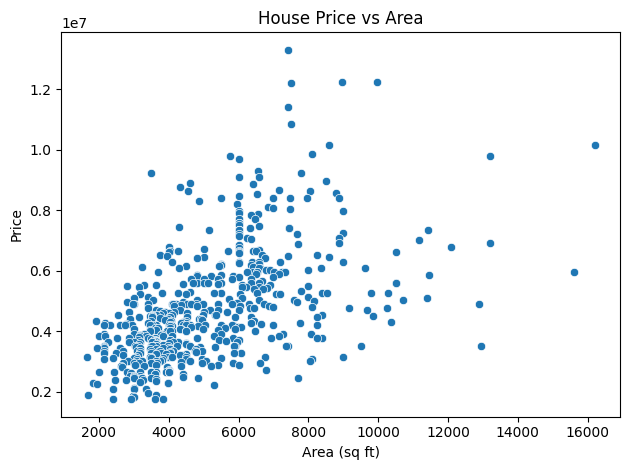

In [5]:
# CELL 6 — EDA: Price vs Area
sns.scatterplot(x='area', y='price', data=df)
plt.title("House Price vs Area")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.tight_layout()
plt.show()
# INSIGHT: Larger area = higher price? Let's see.

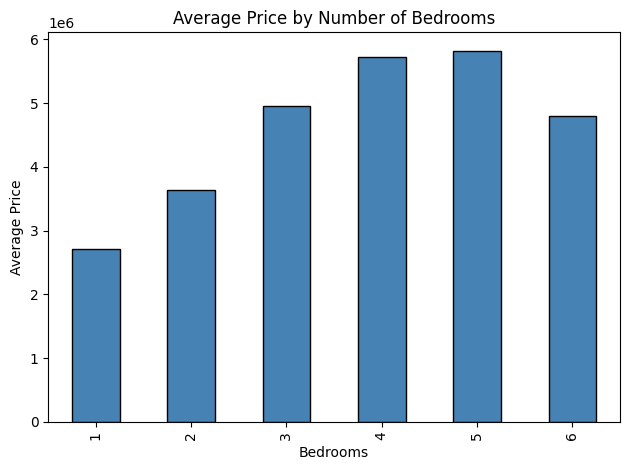

In [6]:
# CELL 7 — EDA: Average price by bedrooms
df.groupby('bedrooms')['price'].mean().plot(kind='bar', 
                                             color='steelblue',
                                             edgecolor='black')
plt.title("Average Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price")
plt.tight_layout()
plt.show()
# INSIGHT: More bedrooms = more expensive? Not always linear.

In [ ]:
# CELL 8 — Handle categorical columns
# Some columns have yes/no or other text values
# ML models only understand numbers so we convert text to numbers
le = LabelEncoder()
categorical_cols = df.select_dtypes(include='object').columns
print("Categorical columns found:", categorical_cols.tolist())

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("All columns converted to numbers successfully")
df.head()

Categorical columns found: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
All columns converted to numbers successfully


C:\Users\PC User\AppData\Local\Temp\ipykernel_8648\2013094620.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


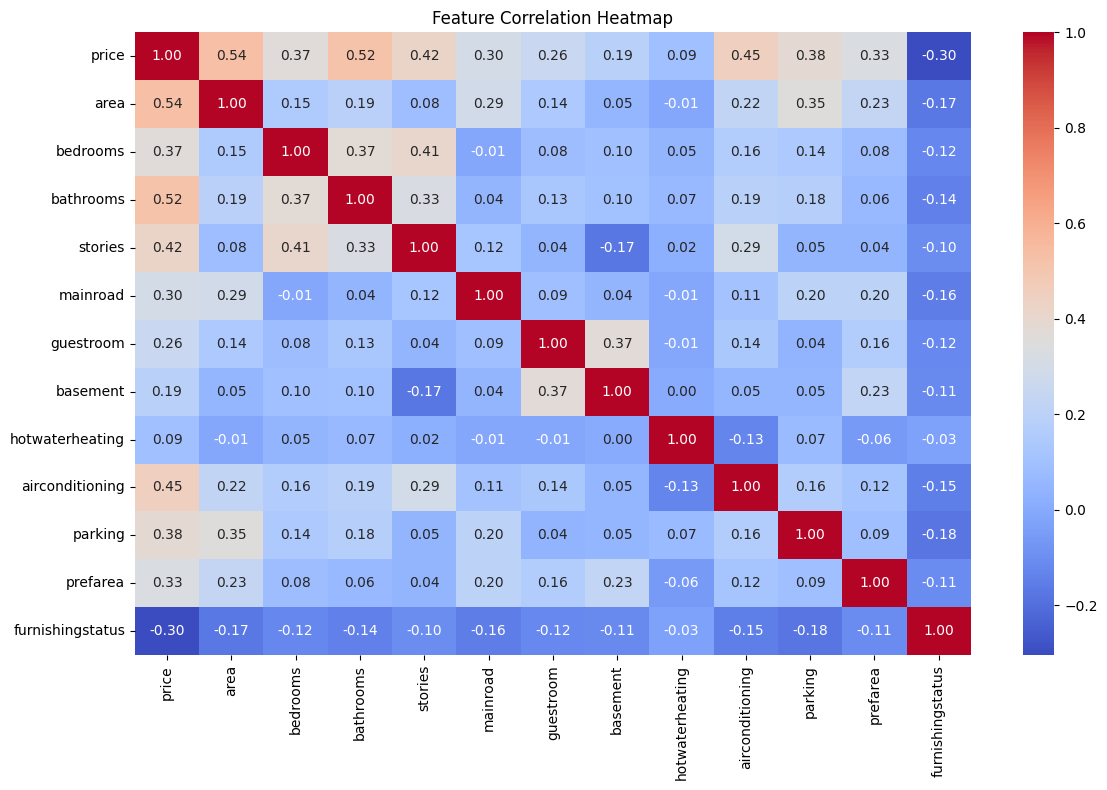

In [8]:
# CELL 9 — Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()
# INSIGHT: Which features are most correlated with price?

In [9]:
# CELL 10 — Split features and target
# X = all columns except price (inputs)
# y = price column (what we predict)
X = df.drop(columns='price')
y = df['price']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (545, 12)
y shape: (545,)


In [10]:
# CELL 11 — Train/Test Split
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 436
Testing samples: 109


In [11]:
# CELL 12 — Train Linear Regression
# Linear Regression finds best straight line through data points
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

print("Linear Regression Results:")
print(f"MAE:  {lr_mae:,.0f}")
print(f"RMSE: {lr_rmse:,.0f}")

Linear Regression Results:
MAE:  979,680
RMSE: 1,331,071


In [13]:
# CELL 13 — Train Gradient Boosting
# More powerful model — combines many weak models into one strong model
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_preds)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))

print("Gradient Boosting Results:")
print(f"MAE:  {gb_mae:,.0f}")
print(f"RMSE: {gb_rmse:,.0f}")

Gradient Boosting Results:
MAE:  964,059
RMSE: 1,301,872


In [14]:
# CELL 14 — Compare both models
print("=" * 40)
print("MODEL COMPARISON")
print("=" * 40)
print(f"Linear Regression  → MAE: {lr_mae:,.0f} | RMSE: {lr_rmse:,.0f}")
print(f"Gradient Boosting  → MAE: {gb_mae:,.0f} | RMSE: {gb_rmse:,.0f}")
print("=" * 40)
print("Lower MAE and RMSE = Better model")

MODEL COMPARISON
Linear Regression  → MAE: 979,680 | RMSE: 1,331,071
Gradient Boosting  → MAE: 964,059 | RMSE: 1,301,872
Lower MAE and RMSE = Better model


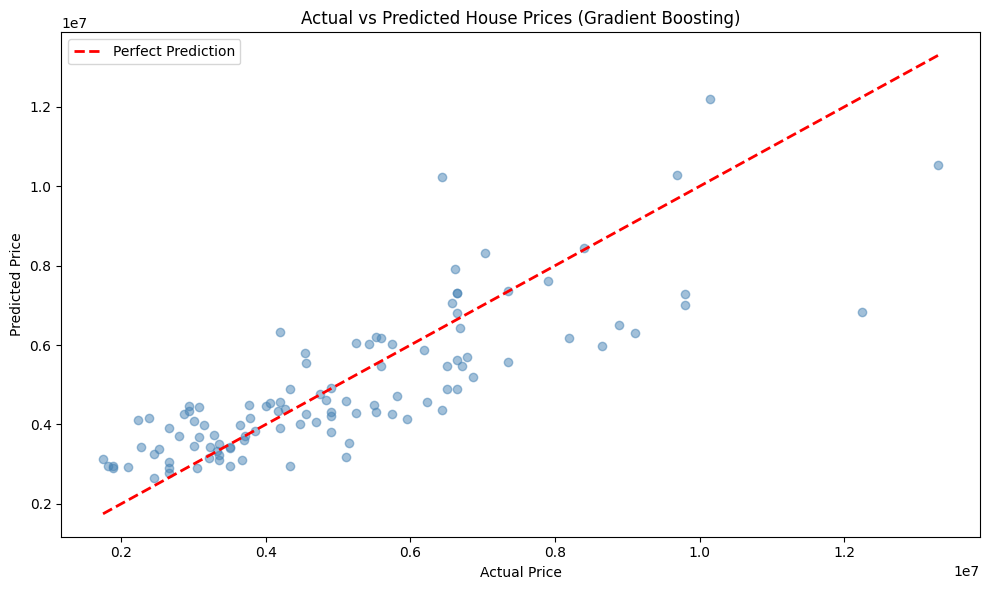

In [15]:
# CELL 15 — Actual vs Predicted plot (Gradient Boosting)
plt.figure(figsize=(10,6))
plt.scatter(y_test, gb_preds, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.title("Actual vs Predicted House Prices (Gradient Boosting)")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.tight_layout()
plt.show()
# INSIGHT: Points closer to red line = better predictions

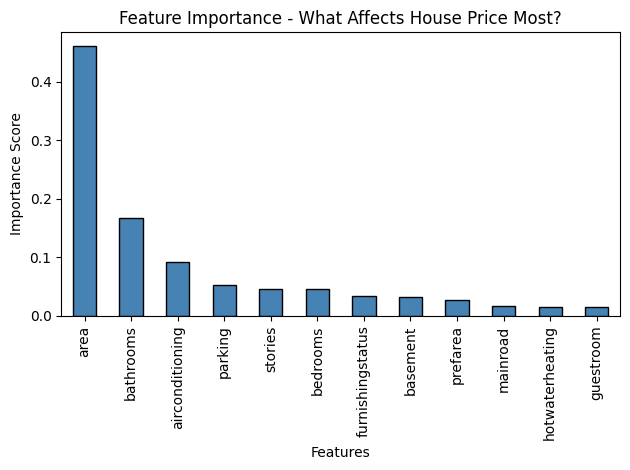

In [16]:
# CELL 16 — Feature Importance (Gradient Boosting)
importance = pd.Series(
    gb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Feature Importance - What Affects House Price Most?")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()
# INSIGHT: Which feature affects house price the most?

In [17]:
# CELL 17 — Final Summary
print("TASK 6 - HOUSE PRICE PREDICTION SUMMARY")
print("=" * 45)
print(f"Dataset size: {df.shape[0]} houses, {df.shape[1]} features")
print(f"Best Model: Gradient Boosting")
print(f"MAE:  {gb_mae:,.0f} (avg prediction error in price units)")
print(f"RMSE: {gb_rmse:,.0f} (punishes large errors more)")
print("=" * 45)

TASK 6 - HOUSE PRICE PREDICTION SUMMARY
Dataset size: 545 houses, 13 features
Best Model: Gradient Boosting
MAE:  964,059 (avg prediction error in price units)
RMSE: 1,301,872 (punishes large errors more)
